# DTR Navigation in Windy Mini Grid Environment

This notebook demonstrates how to use the Dynamic Treatment Regime (DTR) approach to navigate through a windy grid world environment. We'll use the ExtendedWindyGridSCM class that integrates DTR with the mini-grid environment.

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium.utils.play import play
import minigrid 
from minigrid.wrappers import ImgObsWrapper
from minigrid.core.world_object import Goal, Lava

# Import causal gym components
from causal_gym.envs import CustomCrossingEnv
from causal_gym.envs import WindyMiniGridPCH
from causal_gym.envs.extended_windy_grid import ExtendedWindyGridPCH
%matplotlib inline
# Import DTR model
from causal_gym.envs.dtr_example import DTRExamplePCH
from utilities import run_one_pass, run_multiple_passes_extended_windy_mingrid


# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)

## Creating the Environment

We'll create a custom lava crossing environment and wrap it with our extended windy grid wrapper that integrates DTR.


In [2]:
# Create the base environment
lavagrid = gym.make('MiniGrid-LavaGapS6-v0', max_episode_steps=30, 
                   agent_pov=False, render_mode='rgb_array', 
                   highlight=False, tile_size=32)

# Create the extended windy grid with DTR decision model
ext_windy_lavagrid = ExtendedWindyGridPCH(
    env=lavagrid, 
    decision_type='DTR',
    show_wind=True, 
    wind_dist=[.2, .2, .2, .2, .2]  # Equal probability for all wind directions
)

# Reset the environment
observation, info = ext_windy_lavagrid.reset(seed=SEED)
print(f"Initial State (S1): {observation}")
print(f"Initial Wind Direction: {info['wind']}")

Initial State (S1): (1, 1)
Initial Wind Direction: 3


## Single Pass Demonstration

Let's first demonstrate a single pass with a few steps, showing the state transitions in the DTR model.


In [3]:
EXPLORATION_RATE = 0.2  # 20% chance to take a random action

def behavior_policy1(state, wind):
    """First stage policy with exploration (S1 -> X1)"""
    s1 = ext_windy_lavagrid.env._map_grid_to_dtr_s1()
    # Base policy: Forward if S1=1
    base_action = 1 if s1 == 0 else 2
    # With probability EXPLORATION_RATE, take a random action
    if np.random.random() < EXPLORATION_RATE:
        # Choose randomly from available actions: 0=right, 1=forward, 2=left, 3=Stay
        action = np.random.choice([0, 1, 2, 3])
    else:
        action = base_action
    return ext_windy_lavagrid.env._map_decision_to_grid_action(action)

def behavior_policy2(state, wind):
    """Second stage policy with exploration (S1, X1, S2 -> X2)"""
    s2 = ext_windy_lavagrid.env._map_grid_to_dtr_s2()
    # Base policy: Right if S2=1
    base_action = 0 if s2 == 0 else 3 
    # With probability EXPLORATION_RATE, take a random action
    if np.random.random() < EXPLORATION_RATE:
        # Choose randomly from available actions: 0=right, 1=forward, 2=left, 3=Stay
        action = np.random.choice([0, 1, 2, 3])
    else:
        action = base_action
    return ext_windy_lavagrid.env._map_decision_to_grid_action(action)

Initial position: [1 1]
Initial wind: 3
DTR stage: 0
S1 (derived from position): 1

Step 1:
Action taken: 0
New position: [1 1]
Wind direction: 2
DTR stage: 1
S2 (derived from position): 1
Reward: -0.1

Step 2:
Action taken: 6
New position: [1 1]
Wind direction: 4
DTR stage: 2
DTR complete: True
Reward: 0.4

Resetting DTR model for new episode (keeping grid position)...
New DTR stage after reset: 0

Step 3 (First step of new DTR episode):
Action taken: 0
New position: [1 1]
Wind direction: 3
DTR stage: 1
Reward: -0.1

Step 4 (Second step of new DTR episode):
Action taken: 6
New position: [1 1]
Wind direction: 0
DTR stage: 2
DTR complete: True
Reward: 0.4


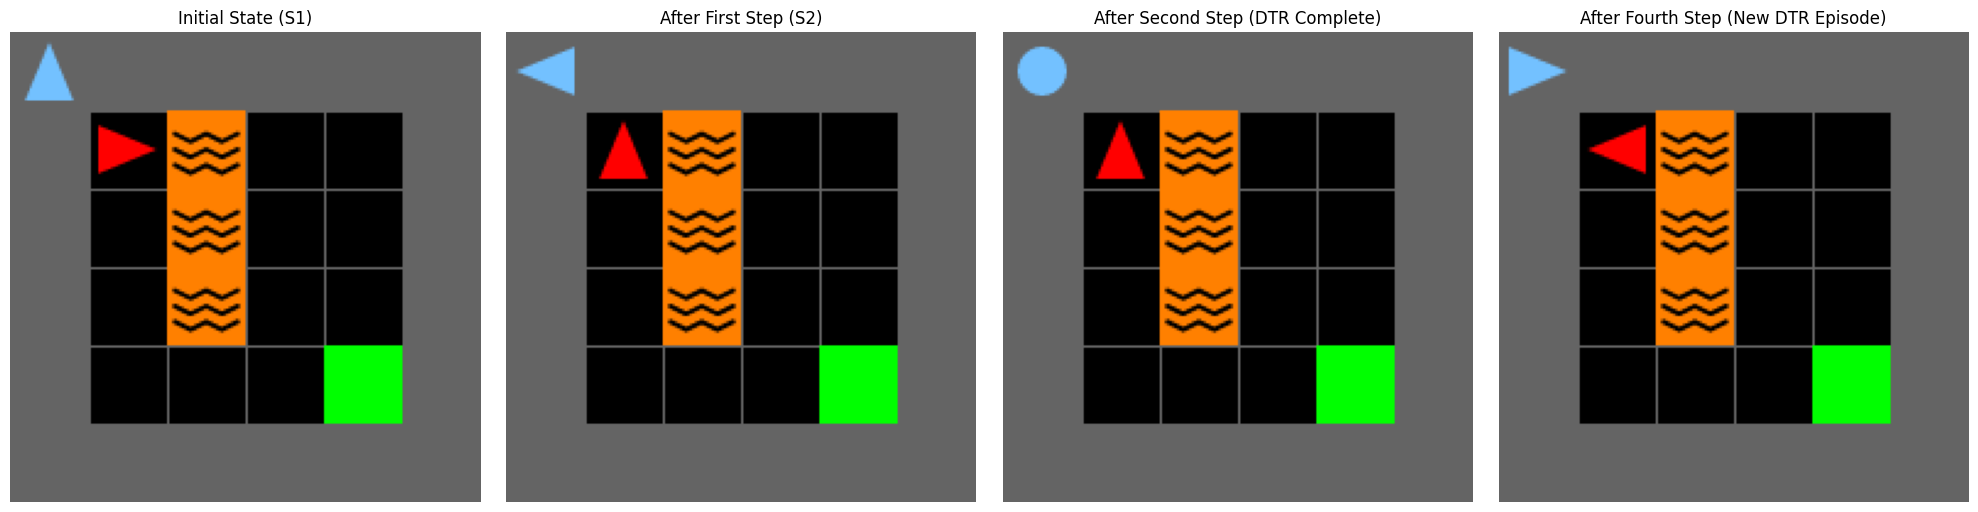

In [4]:
run_one_pass(ext_windy_lavagrid=ext_windy_lavagrid, behavior_policy1=behavior_policy1, behavior_policy2=behavior_policy2, SEED=SEED)

## Multiple Passes Through the Environment

Now, let's run 100 passes through the environment and collect statistics.

In [5]:
num_passes = 1000
    
results = run_multiple_passes_extended_windy_mingrid(num_passes, Goal=Goal, ext_windy_lavagrid=ext_windy_lavagrid, behavior_policy1=behavior_policy1, behavior_policy2=behavior_policy2, SEED=SEED)
# Convert results to numpy arrays for analysis
pass_indices = np.array([r['pass_idx'] for r in results])
rewards = np.array([r['total_reward'] for r in results])
steps = np.array([r['steps_taken'] for r in results])
dtr_episodes = np.array([r['dtr_episodes_completed'] for r in results])
grid_goals = np.array([r['grid_goals_reached'] for r in results])

# Calculate statistics
avg_reward = np.mean(rewards)
avg_steps = np.mean(steps)
avg_dtr_episodes = np.mean(dtr_episodes)
avg_grid_goals = np.mean(grid_goals)

print(f"\nResults after {num_passes} passes:")
print(f"Average reward: {avg_reward:.2f}")
print(f"Average steps per pass: {avg_steps:.2f}")
print(f"Average DTR episodes completed per pass: {avg_dtr_episodes:.2f}")
print(f"Average grid goals reached per pass: {avg_grid_goals:.2f}")


Results after 1000 passes:
Average reward: 3.56
Average steps per pass: 24.75
Average DTR episodes completed per pass: 12.16
Average grid goals reached per pass: 0.00


## Analyzing the Results

Let's visualize the results of our 100 passes.

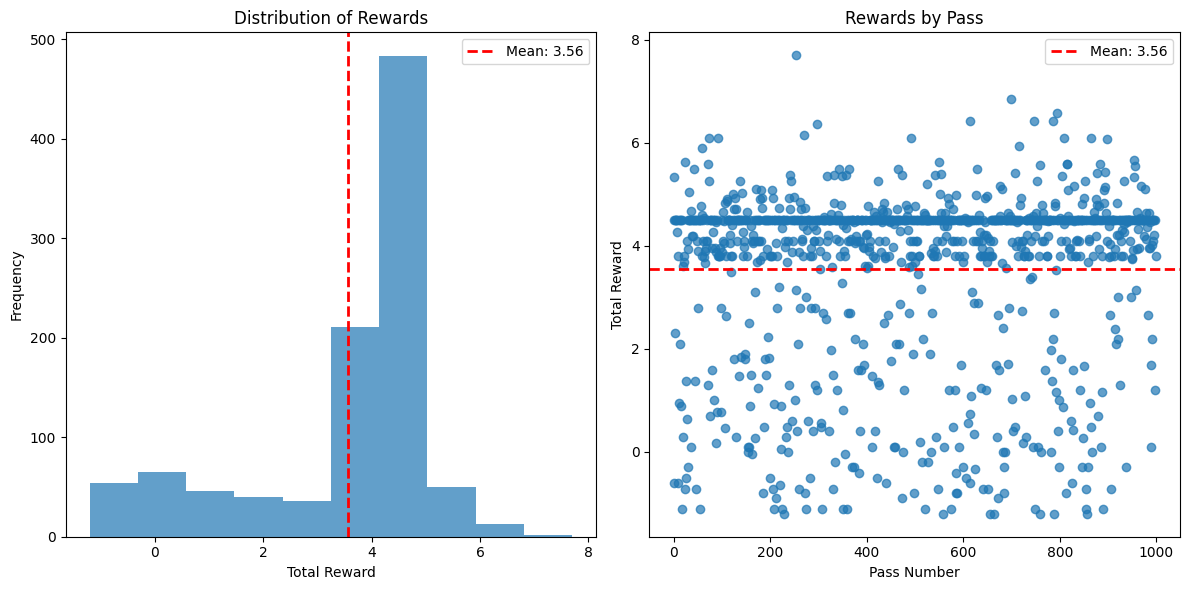

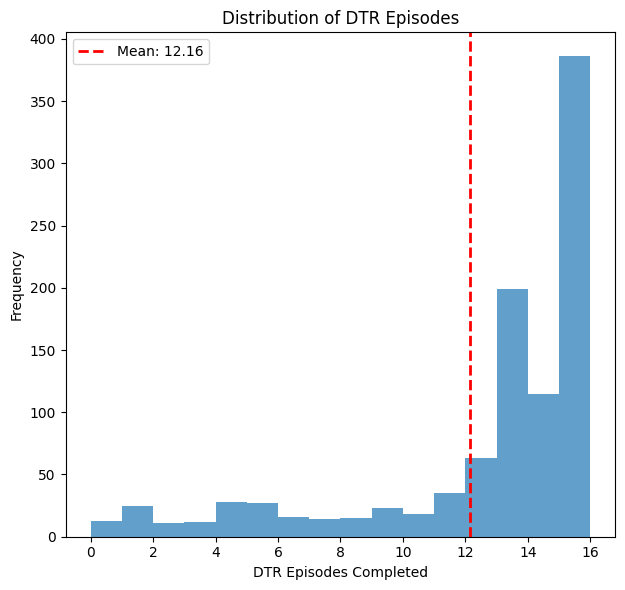

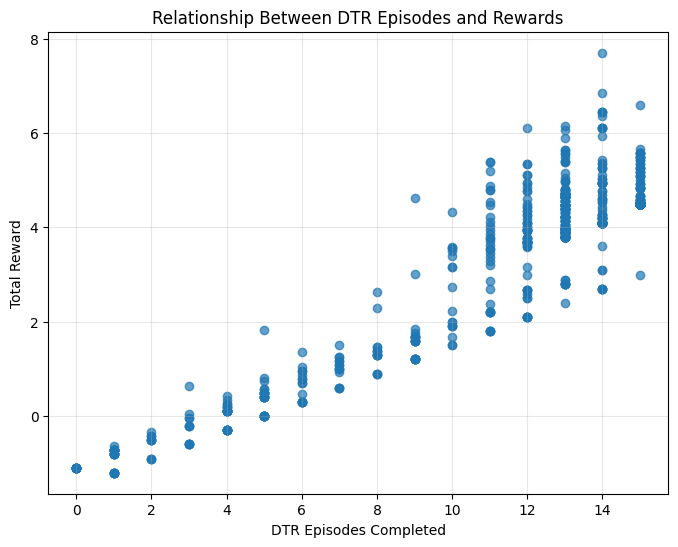

In [6]:
# Visualize rewards distribution
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(rewards, bins=10, alpha=0.7)
plt.axvline(avg_reward, color='r', linestyle='dashed', linewidth=2, label=f'Mean: {avg_reward:.2f}')
plt.xlabel('Total Reward')
plt.ylabel('Frequency')
plt.title('Distribution of Rewards')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(pass_indices, rewards, alpha=0.7)
plt.axhline(avg_reward, color='r', linestyle='dashed', linewidth=2, label=f'Mean: {avg_reward:.2f}')
plt.xlabel('Pass Number')
plt.ylabel('Total Reward')
plt.title('Rewards by Pass')
plt.legend()

plt.tight_layout()
plt.show()

# Visualize DTR episodes and grid goals
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(dtr_episodes, bins=range(max(dtr_episodes)+2), alpha=0.7)
plt.axvline(avg_dtr_episodes, color='r', linestyle='dashed', linewidth=2, label=f'Mean: {avg_dtr_episodes:.2f}')
plt.xlabel('DTR Episodes Completed')
plt.ylabel('Frequency')
plt.title('Distribution of DTR Episodes')
plt.legend()

plt.tight_layout()
plt.show()

# Scatter plot of DTR episodes vs rewards
plt.figure(figsize=(8, 6))
plt.scatter(dtr_episodes, rewards, alpha=0.7)
plt.xlabel('DTR Episodes Completed')
plt.ylabel('Total Reward')
plt.title('Relationship Between DTR Episodes and Rewards')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# Collect observational data for IPW evaluation
def collect_observational_data(env, num_episodes=1000, max_steps_per_episode=30):
    """
    Collect observational trajectories from the extended windy grid DTR environment
    
    Returns:
        trajectories: List of trajectory dictionaries
    """
    trajectories = []
    
    for episode_idx in range(num_episodes):
        env.reset(seed=SEED + episode_idx)
        
        # Store the complete trajectory for this episode
        episode_trajectory = {
            'states': [],  # Grid positions
            'states_dtr_s1': [],  # DTR S1 states
            'actions_dtr_x1': [],  # DTR X1 actions
            'states_dtr_s2': [],  # DTR S2 states
            'actions_dtr_x2': [],  # DTR X2 actions
            'rewards': [],  # Rewards received
            'episode_reward': 0.0,  # Total episode reward
            'steps': 0
        }
        
        terminated = False
        truncated = False
        steps = 0
        
        while not (terminated or truncated) and steps < max_steps_per_episode:
            # Check DTR stage and use appropriate policy
            if env.env.decision_model.stage == 0:
                # First stage of DTR episode
                s1 = env.env._map_grid_to_dtr_s1()
                action, next_state, reward, terminated, truncated, info = env.see(bpolicy=behavior_policy1)
                
                # Record the transition
                episode_trajectory['states'].append(env.env.agent_pos)
                episode_trajectory['states_dtr_s1'].append(s1)
                episode_trajectory['actions_dtr_x1'].append(env.env._map_grid_to_decision_action(action))
                episode_trajectory['rewards'].append(reward)
                episode_trajectory['episode_reward'] += reward
                
            else:
                # Second stage of DTR episode
                s1 = env.env._map_grid_to_dtr_s1()
                s2 = env.env._map_grid_to_dtr_s2()
                x1 = episode_trajectory['actions_dtr_x1'][-1] if episode_trajectory['actions_dtr_x1'] else 0
                
                action, next_state, reward, terminated, truncated, info = env.see(bpolicy=behavior_policy2)
                
                # Record the transition
                episode_trajectory['states_dtr_s2'].append(s2)
                episode_trajectory['actions_dtr_x2'].append(env.env._map_grid_to_decision_action(action))
                episode_trajectory['rewards'].append(reward)
                episode_trajectory['episode_reward'] += reward
                
                # Check if DTR episode completed
                if env.env.dtr_complete:
                    # Reset DTR model but keep grid position
                    env.env.decision_model.reset()
                    env.env.dtr_complete = False
                    env.env.dtr_episode_reward = 0.0
            
            steps += 1
            episode_trajectory['steps'] = steps
        
        trajectories.append(episode_trajectory)
        
        if (episode_idx + 1) % 100 == 0:
            print(f"Collected {episode_idx + 1} trajectories")
    
    return trajectories

# Collect observational data
print("Collecting observational data...")
observational_trajectories = collect_observational_data(ext_windy_lavagrid, num_episodes=1000)

# Analyze the collected data
total_rewards = [traj['episode_reward'] for traj in observational_trajectories]
avg_observational_reward = np.mean(total_rewards)
std_observational_reward = np.std(total_rewards)

print(f"\nObservational Policy Performance:")
print(f"Average episode reward: {avg_observational_reward:.3f} ± {std_observational_reward:.3f}")
print(f"Min reward: {np.min(total_rewards):.3f}")
print(f"Max reward: {np.max(total_rewards):.3f}")

Collected 100 trajectories
Collected 200 trajectories
Collected 300 trajectories
Collected 400 trajectories
Collected 500 trajectories
Collected 600 trajectories
Collected 700 trajectories
Collected 800 trajectories
Collected 900 trajectories
Collected 1000 trajectories

Observational Policy Performance:
Average episode reward: 3.559 ± 1.733
Min reward: -1.200
Max reward: 6.850


In [8]:
def compute_propensity_scores_windy_dtr(trajectories):
    """
    Compute propensity scores for the windy DTR environment
    
    Returns:
        propensity_scores: Dictionary with propensity scores for each decision point
    """
    # Initialize counters for computing propensities
    counts_s1_x1 = {}  # P(X1|S1)
    counts_s1_x1_s2_x2 = {}  # P(X2|S1,X1,S2)
    
    # Process trajectories to count state-action pairs
    for traj in trajectories:
        # Process all DTR episodes in this trajectory
        for i in range(len(traj['states_dtr_s1'])):
            s1 = traj['states_dtr_s1'][i]
            x1 = traj['actions_dtr_x1'][i]
            
            # Count S1 -> X1 transitions
            if s1 not in counts_s1_x1:
                counts_s1_x1[s1] = {}
            if x1 not in counts_s1_x1[s1]:
                counts_s1_x1[s1][x1] = 0
            counts_s1_x1[s1][x1] += 1
        
        # Process S2 actions (making sure we have matched S1-X1 pairs)
        min_len = min(len(traj['states_dtr_s2']), len(traj['actions_dtr_x2']))
        for i in range(min_len):
            if i < len(traj['states_dtr_s1']) and i < len(traj['actions_dtr_x1']):
                s1 = traj['states_dtr_s1'][i]
                x1 = traj['actions_dtr_x1'][i]
                s2 = traj['states_dtr_s2'][i]
                x2 = traj['actions_dtr_x2'][i]
                
                # Count S1,X1,S2 -> X2 transitions
                key = (s1, x1, s2)
                if key not in counts_s1_x1_s2_x2:
                    counts_s1_x1_s2_x2[key] = {}
                if x2 not in counts_s1_x1_s2_x2[key]:
                    counts_s1_x1_s2_x2[key][x2] = 0
                counts_s1_x1_s2_x2[key][x2] += 1
    
    # Convert counts to propensity scores
    propensity_s1_x1 = {}
    for s1, action_counts in counts_s1_x1.items():
        total = sum(action_counts.values())
        propensity_s1_x1[s1] = {x1: count/total for x1, count in action_counts.items()}
    
    propensity_s1_x1_s2_x2 = {}
    for (s1, x1, s2), action_counts in counts_s1_x1_s2_x2.items():
        total = sum(action_counts.values())
        propensity_s1_x1_s2_x2[(s1, x1, s2)] = {x2: count/total for x2, count in action_counts.items()}
    
    return {
        'p_x1_given_s1': propensity_s1_x1,
        'p_x2_given_s1_x1_s2': propensity_s1_x1_s2_x2
    }

# Compute propensity scores
print("Computing propensity scores...")
propensity_scores = compute_propensity_scores_windy_dtr(observational_trajectories)

print("Sample propensity scores:")
print("P(X1|S1):")
for s1, probs in list(propensity_scores['p_x1_given_s1'].items())[:3]:
    print(f"  S1={s1}: {probs}")

print("\nP(X2|S1,X1,S2):")
for key, probs in list(propensity_scores['p_x2_given_s1_x1_s2'].items())[:3]:
    print(f"  {key}: {probs}")

Computing propensity scores...
Sample propensity scores:
P(X1|S1):
  S1=1: {0: 0.8525708715782634, 3: 0.05182357241491349, 1: 0.04759970757858825, 2: 0.04800584842823491}
  S1=0: {0: 0.05067567567567568, 2: 0.847972972972973, 3: 0.05067567567567568, 1: 0.05067567567567568}

P(X2|S1,X1,S2):
  (1, 0, 1): {3: 0.8457513604018417, 0: 0.051799916282963585, 1: 0.04918375889493512, 2: 0.05326496442025952}
  (1, 3, 1): {3: 0.8537005163511188, 0: 0.0378657487091222, 2: 0.05679862306368331, 1: 0.05163511187607573}
  (0, 0, 1): {3: 1.0}


In [9]:
# Define a More Reasonable Alternative Policy

# Let's also create alternative policies that are different but reasonable
def alternative_policy1(state, wind):
    """Alternative policy 1: Prefers different actions than base policy"""
    s1 = ext_windy_lavagrid.env._map_grid_to_dtr_s1()
    # Opposite preferences: Forward if S1=0, Right if S1=1
    action = 2 if s1 == 0 else 1
    return ext_windy_lavagrid.env._map_decision_to_grid_action(action)

def alternative_policy2(state, wind):
    """Alternative policy 2: Prefers different actions than base policy"""
    s2 = ext_windy_lavagrid.env._map_grid_to_dtr_s2()
    # Opposite preferences: Stay if S2=0, Left if S2=1
    action = 3 if s2 == 0 else 0
    return ext_windy_lavagrid.env._map_decision_to_grid_action(action)

# Define policies to evaluate - now just comparing behavior vs one alternative
policies_to_evaluate = [
    ("Behavior Policy", behavior_policy1, behavior_policy2),
    ("Alternative Actions Policy", alternative_policy1, alternative_policy2),
]


print("Defined alternative policies for evaluation")

Defined alternative policies for evaluation


# Mathematical Explanation of IPW Evaluation for Extended Windy Grid DTR Environment

## 1. Background: Inverse Propensity Weighting (IPW)

**IPW** is a method for evaluating policies using observational data. The key idea is to correct for the bias introduced by the behavioral policy by reweighting trajectories according to their likelihood under the target policy versus the behavioral policy.

## 2. The IPW Formula

For a policy $\pi = (\pi_1, \pi_2)$ in our DTR environment, the IPW estimator is:

$$\hat{V}^{\text{IPW}}(\pi) = \frac{1}{N} \sum_{i=1}^{N} \frac{\pi_1(X_1^{(i)}|S_1^{(i)}) \cdot \pi_2(X_2^{(i)}|S_1^{(i)}, X_1^{(i)}, S_2^{(i)})}{b_1(X_1^{(i)}|S_1^{(i)}) \cdot b_2(X_2^{(i)}|S_1^{(i)}, X_1^{(i)}, S_2^{(i)})} \cdot R^{(i)}$$

Where:
- $\pi_1, \pi_2$: Target policy functions (what we want to evaluate)
- $b_1, b_2$: Behavioral policy functions (what generated the data)
- $S_1, S_2$: States in the DTR (derived from grid position)
- $X_1, X_2$: Actions in the DTR
- $R^{(i)}$: Total episode reward for trajectory $i$
- $N$: Number of trajectories

## 3. Variables in Our Extended Windy Grid Environment

### States
- **$S_1$**: First stage state = `agent_pos[0] % 2` (x-coordinate mod 2)
- **$S_2$**: Second stage state = `agent_pos[1] % 2` (y-coordinate mod 2)
- These map the continuous grid position to binary DTR states

### Actions
Our environment uses 4 possible actions mapped to DTR actions:
- **0**: Right
- **1**: Forward
- **2**: Left
- **3**: Stay

### Behavioral Policy
Our behavioral policy with exploration rate $\epsilon = 0.1$:
```python
# Stage 1: Choose action 1 if S1=0, action 2 if S1=1, with 20% exploration
# Stage 2: Choose action 0 if S2=0, action 3 if S2=1, with 20% exploration

In [10]:
# Let's also modify the IPW implementation to handle zero probabilities gracefully
def ipw_evaluate_policy_windy_dtr(trajectories, propensity_scores, policy1, policy2):
    """
    Improved IPW evaluation that handles support issues better
    """
    total_weighted_reward = 0.0
    total_weight = 0.0
    valid_trajectories = 0
    support_issues = 0
    
    for traj in trajectories:
        trajectory_weight = 1.0
        trajectory_reward = 0.0
        valid_trajectory = True
        
        # Process each DTR episode in the trajectory
        dtr_episodes = min(len(traj['states_dtr_s1']), len(traj['states_dtr_s2']))
        
        for episode_idx in range(dtr_episodes):
            # Get states and actions for this DTR episode
            s1 = traj['states_dtr_s1'][episode_idx]
            x1_obs = traj['actions_dtr_x1'][episode_idx]
            
            if episode_idx < len(traj['states_dtr_s2']) and episode_idx < len(traj['actions_dtr_x2']):
                s2 = traj['states_dtr_s2'][episode_idx]
                x2_obs = traj['actions_dtr_x2'][episode_idx]
            else:
                valid_trajectory = False
                break
            
            # Get policy decisions for this specific trajectory
            # For behavior policy, match observed actions
            if policy1 == behavior_policy1:
                x1_policy = x1_obs  # Behavior policy matches observation
            else:
                # Alternative policy (swapped actions)
                x1_policy = 2 if s1 == 0 else 1
            
            if policy2 == behavior_policy2:
                x2_policy = x2_obs  # Behavior policy matches observation
            else:
                # Alternative policy (swapped actions)
                x2_policy = 3 if s2 == 0 else 0
            
            # Check if this trajectory matches what our target policy would do
            if x1_policy != x1_obs or x2_policy != x2_obs:
                # This trajectory doesn't match our target policy, skip it
                valid_trajectory = False
                break
            
            # Get propensity scores (check for support issues)
            if s1 not in propensity_scores['p_x1_given_s1']:
                support_issues += 1
                valid_trajectory = False
                break
            if x1_obs not in propensity_scores['p_x1_given_s1'][s1]:
                support_issues += 1
                valid_trajectory = False
                break
                
            key = (s1, x1_obs, s2)
            if key not in propensity_scores['p_x2_given_s1_x1_s2']:
                support_issues += 1
                valid_trajectory = False
                break
            if x2_obs not in propensity_scores['p_x2_given_s1_x1_s2'][key]:
                support_issues += 1
                valid_trajectory = False
                break
            
            # Compute weights
            p_x1 = propensity_scores['p_x1_given_s1'][s1][x1_obs]
            p_x2 = propensity_scores['p_x2_given_s1_x1_s2'][key][x2_obs]
            
            if p_x1 == 0 or p_x2 == 0:
                support_issues += 1
                valid_trajectory = False
                break
            
            # Update trajectory weight (multiply for each DTR episode)
            trajectory_weight *= (1.0 / p_x1) * (1.0 / p_x2)
        
        if valid_trajectory:
            trajectory_reward = traj['episode_reward']
            total_weighted_reward += trajectory_reward * trajectory_weight
            total_weight += trajectory_weight
            valid_trajectories += 1
    
    if total_weight == 0:
        return 0.0, 0, support_issues
    
    ipw_estimate = total_weighted_reward / total_weight
    return ipw_estimate, valid_trajectories, support_issues

# Evaluate the simplified policy comparison
print("\nEvaluating policies with improved IPW (v2)...")
ipw_results = []

for policy_name, policy1, policy2 in policies_to_evaluate:
    print(f"\nEvaluating {policy_name}...")
    ipw_estimate, n_valid, n_support_issues = ipw_evaluate_policy_windy_dtr(
        observational_trajectories, 
        propensity_scores, 
        policy1, 
        policy2
    )
    
    ipw_results.append({
        'policy': policy_name,
        'ipw_estimate': ipw_estimate,
        'n_valid_trajectories': n_valid,
        'support_issues': n_support_issues
    })
    
    print(f"  IPW Estimate: {ipw_estimate:.3f}")
    print(f"  Valid trajectories: {n_valid}/{len(observational_trajectories)}")
    print(f"  Support issues: {n_support_issues}")



Evaluating policies with improved IPW (v2)...

Evaluating Behavior Policy...
  IPW Estimate: 3.429
  Valid trajectories: 1000/1000
  Support issues: 0

Evaluating Alternative Actions Policy...
  IPW Estimate: -1.100
  Valid trajectories: 13/1000
  Support issues: 0


In [11]:
# Directly evaluate policies by running them in the environment
def direct_policy_evaluation(env, policy1, policy2, num_episodes=100):
    """
    Directly evaluate a policy by running it in the environment
    """
    rewards = []
    
    for episode_idx in range(num_episodes):
        env.reset(seed=SEED + episode_idx + 1000)  # Different seeds than observational data
        
        total_reward = 0.0
        terminated = False
        truncated = False
        steps = 0
        
        while not (terminated or truncated) and steps < 30:
            if env.env.decision_model.stage == 0:
                # First stage
                action, next_state, reward, terminated, truncated, info = env.see(bpolicy=policy1)
            else:
                # Second stage
                action, next_state, reward, terminated, truncated, info = env.see(bpolicy=policy2)
            
            total_reward += reward
            steps += 1
            
            # Reset DTR if completed
            if env.env.dtr_complete:
                env.env.decision_model.reset()
                env.env.dtr_complete = False
                env.env.dtr_episode_reward = 0.0
        
        rewards.append(total_reward)
    
    return np.mean(rewards), np.std(rewards)

# Compare IPW estimates with direct evaluation
print("Comparing IPW estimates with direct policy evaluation...")
print("\n" + "="*60)
print(f"{'Policy':<25} {'IPW Estimate':<15} {'Direct Eval':<15} {'Difference':<15}")
print("="*60)

for result in ipw_results:
    policy_name = result['policy']
    ipw_value = result['ipw_estimate']
    
    # Find the corresponding policies
    policy1, policy2 = None, None
    for name, p1, p2 in policies_to_evaluate:
        if name == policy_name:
            policy1, policy2 = p1, p2
            break
    
    if policy1 is not None and policy2 is not None:
        # Direct evaluation
        direct_mean, direct_std = direct_policy_evaluation(ext_windy_lavagrid, policy1, policy2)
        
        # Compare
        difference = abs(ipw_value - direct_mean)
        
        print(f"{policy_name:<25} {ipw_value:<15.3f} {direct_mean:<15.3f} {difference:<15.3f}")
        
        # Store for plotting
        result['direct_evaluation'] = direct_mean
        result['direct_std'] = direct_std
        result['difference'] = difference

Comparing IPW estimates with direct policy evaluation...

Policy                    IPW Estimate    Direct Eval     Difference     
Behavior Policy           3.429           3.671           0.242          
Alternative Actions Policy -1.100          2.669           3.769          


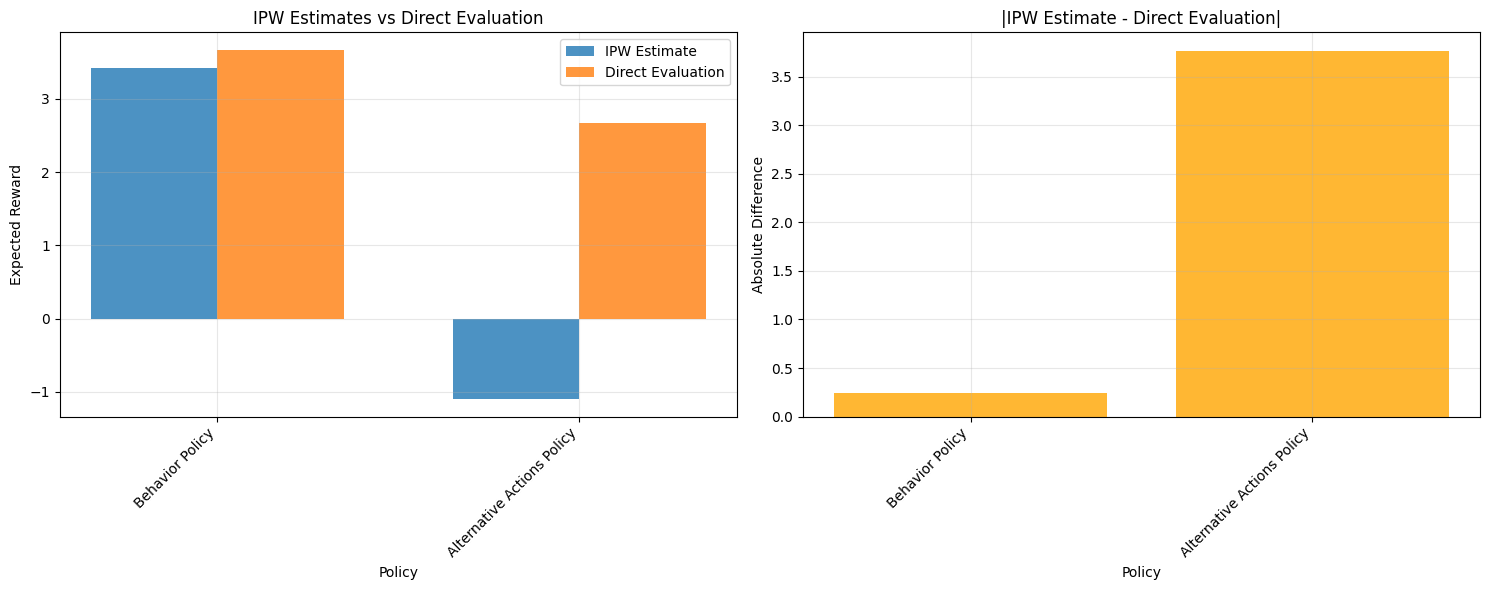


SUMMARY
Average absolute difference: 2.006
Max absolute difference: 3.769
Min absolute difference: 0.242

Best policy according to IPW: Behavior Policy (3.429)

Observational (Behavior) Policy Performance: 3.559
Behavior Policy IPW Estimate: 3.429
IPW vs Observational difference: 0.130


In [12]:
# Create visualization of results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Extract data for plotting
policy_names = [r['policy'] for r in ipw_results]
ipw_values = [r['ipw_estimate'] for r in ipw_results]
direct_values = [r.get('direct_evaluation', 0) for r in ipw_results]
differences = [r.get('difference', 0) for r in ipw_results]

# Plot 1: IPW vs Direct Evaluation
x = np.arange(len(policy_names))
width = 0.35

ax1.bar(x - width/2, ipw_values, width, label='IPW Estimate', alpha=0.8)
ax1.bar(x + width/2, direct_values, width, label='Direct Evaluation', alpha=0.8)

ax1.set_xlabel('Policy')
ax1.set_ylabel('Expected Reward')
ax1.set_title('IPW Estimates vs Direct Evaluation')
ax1.set_xticks(x)
ax1.set_xticklabels(policy_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Absolute Differences
ax2.bar(x, differences, alpha=0.8, color='orange')
ax2.set_xlabel('Policy')
ax2.set_ylabel('Absolute Difference')
ax2.set_title('|IPW Estimate - Direct Evaluation|')
ax2.set_xticks(x)
ax2.set_xticklabels(policy_names, rotation=45, ha='right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Average absolute difference: {np.mean(differences):.3f}")
print(f"Max absolute difference: {np.max(differences):.3f}")
print(f"Min absolute difference: {np.min(differences):.3f}")

# Show which policy is best according to IPW
best_ipw_idx = np.argmax(ipw_values)
print(f"\nBest policy according to IPW: {policy_names[best_ipw_idx]} ({ipw_values[best_ipw_idx]:.3f})")

# Compare with observational policy performance
print(f"\nObservational (Behavior) Policy Performance: {avg_observational_reward:.3f}")
behavior_ipw = [r for r in ipw_results if r['policy'] == 'Behavior Policy'][0]['ipw_estimate']
print(f"Behavior Policy IPW Estimate: {behavior_ipw:.3f}")
print(f"IPW vs Observational difference: {abs(behavior_ipw - avg_observational_reward):.3f}")